# Efficient Frontier â€” U.S. Treasury Allocation

Mean-variance optimization across 6 Treasury maturities (3M, 1Y, 2Y, 5Y, 10Y, 30Y).  
Expected returns = current FRED yields (carry assumption).  
Risk/covariance = historical price return volatility from daily yield changes (duration-mapped).  
Benchmark = iShares Core U.S. Aggregate Bond ETF (AGG) from Yahoo Finance.

In [1]:
# Install yfinance if needed
import importlib
if importlib.util.find_spec('yfinance') is None:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'yfinance', '-q'])

In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import minimize
import yfinance as yf

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# Project root
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'raw' / 'fred'

In [3]:
# â”€â”€ Parameters â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

TENORS = {
    'DGS3MO': {'label': '3M',  'duration': 0.25},
    'DGS1':   {'label': '1Y',  'duration': 0.97},
    'DGS2':   {'label': '2Y',  'duration': 1.91},
    'DGS5':   {'label': '5Y',  'duration': 4.49},
    'DGS10':  {'label': '10Y', 'duration': 8.11},
    'DGS30':  {'label': '30Y', 'duration': 15.37},
}

LOOKBACK_YEARS = 5    # years of history for covariance estimation
ALLOCATION      = 80_000  # dollars to allocate
BENCHMARK       = 'AGG'

## 1. Load Treasury Yield Data

In [4]:
series_frames = []
for series_id, meta in TENORS.items():
    path = DATA_DIR / f'{series_id}.csv'
    df = pd.read_csv(path, parse_dates=['date'])
    df = df.set_index('date')[['value']].rename(columns={'value': meta['label']})
    series_frames.append(df)

yields_daily = pd.concat(series_frames, axis=1).sort_index()

# Trim to lookback window
cutoff = yields_daily.index.max() - pd.DateOffset(years=LOOKBACK_YEARS)
yields_daily = yields_daily[yields_daily.index >= cutoff]

# Resample to month-end (last observation per month)
yields_monthly = yields_daily.resample('ME').last().dropna()

print(f"Date range: {yields_monthly.index[0].date()} â†’ {yields_monthly.index[-1].date()}")
print(f"Months:     {len(yields_monthly)}")
print(f"\nLatest yields (%):\n{yields_monthly.iloc[-1].to_string()}")

Date range: 2021-04-30 â†’ 2026-04-30
Months:     61

Latest yields (%):
3M     3.70
1Y     3.68
2Y     3.79
5Y     3.94
10Y    4.31
30Y    4.88


## 2. Fetch AGG Benchmark (Yahoo Finance)

In [5]:
start_str = str(yields_monthly.index[0].date())
end_str   = str(yields_monthly.index[-1].date())

raw_agg = yf.download(BENCHMARK, start=start_str, end=end_str,
                      auto_adjust=True, progress=False)

# Handle multi-level columns that yfinance sometimes returns
if isinstance(raw_agg.columns, pd.MultiIndex):
    raw_agg.columns = raw_agg.columns.get_level_values(0)

agg_monthly    = raw_agg['Close'].resample('ME').last()
agg_ret_m      = agg_monthly.pct_change().dropna()
agg_ann_return = float(agg_ret_m.mean() * 12)
agg_ann_vol    = float(agg_ret_m.std() * np.sqrt(12))

print(f"AGG  return (ann): {agg_ann_return*100:.2f}%")
print(f"AGG  vol    (ann): {agg_ann_vol*100:.2f}%")

AGG  return (ann): 0.41%
AGG  vol    (ann): 6.46%


## 3. Compute Price Returns

For a bond held one period, the total return is approximately:

$$r_t \approx -D_{\text{mod}} \cdot \Delta y_t$$

where $\Delta y_t$ is the monthly change in yield (in decimal) and $D_{\text{mod}}$ is the modified duration of a par bond at that maturity.

In [6]:
labels   = [meta['label']    for meta in TENORS.values()]
durations = {meta['label']: meta['duration'] for meta in TENORS.values()}

# Monthly yield changes in decimal
dy_monthly = yields_monthly.diff().dropna() / 100

# Price returns: r â‰ˆ -D * Î”y
price_returns = pd.DataFrame(index=dy_monthly.index)
for lbl, dur in durations.items():
    price_returns[lbl] = -dur * dy_monthly[lbl]

price_returns = price_returns.dropna()
print(f"Monthly price return sample ({len(price_returns)} months):")
price_returns.describe().round(4)

Monthly price return sample (60 months):


,3M,1Y,2Y,5Y,10Y,30Y
count,60.0000,60.0000,60.0000,60.0000,60.0000,60.0000
mean,-0.0002,-0.0006,-0.0012,-0.0023,-0.0036,-0.0066
std,0.0006,0.0025,0.0059,0.0139,0.0225,0.0374
min,-0.0022,-0.0070,-0.0160,-0.0341,-0.0551,-0.0815
25%,-0.0003,-0.0020,-0.0051,-0.0100,-0.0182,-0.0281
50%,-0.0000,-0.0000,-0.0002,-0.0025,-0.0016,-0.0061
75%,0.0001,0.0007,0.0025,0.0077,0.0107,0.0215
max,0.0012,0.0039,0.0143,0.0260,0.0414,0.0784


## 4. Portfolio Inputs â€” Î¼, Î£

In [7]:
# Expected returns = current yield (annualized, decimal)
# Assumption: yield is earned as carry; no expected yield change (random walk)
latest_yields = yields_monthly.iloc[-1]   # percent
mu = (latest_yields / 100).values          # decimal, annualized

# Covariance: annualise monthly price-return cov (Ã— 12)
cov = price_returns.cov().values * 12

# Risk-free = 3-month T-bill yield
rf = mu[labels.index('3M')]

print(f"Risk-free (3M): {rf*100:.2f}%")
print("\nExpected returns:")
for lbl, m in zip(labels, mu):
    print(f"  {lbl:>3s}: {m*100:.2f}%")
print("\nAnnualised volatilities:")
for lbl, v in zip(labels, np.sqrt(np.diag(cov))):
    print(f"  {lbl:>3s}: {v*100:.2f}%")

Risk-free (3M): 3.70%

Expected returns:
   3M: 3.70%
   1Y: 3.68%
   2Y: 3.79%
   5Y: 3.94%
  10Y: 4.31%
  30Y: 4.88%

Annualised volatilities:
   3M: 0.19%
   1Y: 0.85%
   2Y: 2.04%
   5Y: 4.82%
  10Y: 7.81%
  30Y: 12.94%


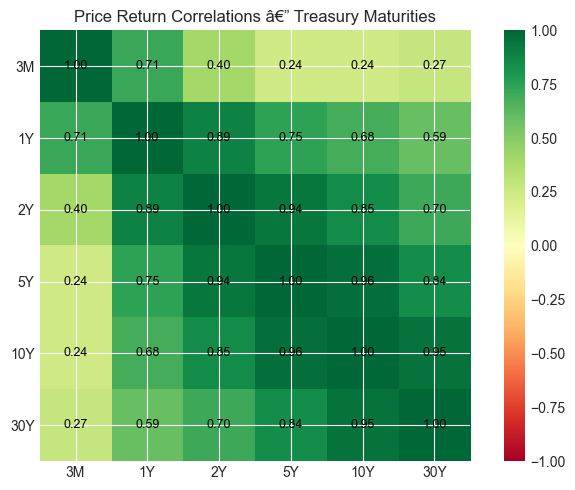

In [8]:
# Correlation heatmap
corr_df = price_returns.corr()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr_df.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr_df.values[i, j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='black')
ax.set_title('Price Return Correlations â€” Treasury Maturities')
plt.tight_layout()
plt.show()

## 5. Efficient Frontier Optimisation

In [9]:
n = len(labels)

def port_return(w): return w @ mu
def port_vol(w):    return np.sqrt(w @ cov @ w)
def neg_sharpe(w):  return -(port_return(w) - rf) / port_vol(w)

base_constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
bounds = [(0.0, 1.0)] * n   # long-only
w0     = np.ones(n) / n

# â”€â”€ Frontier sweep â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
target_returns = np.linspace(mu.min(), mu.max(), 200)
frontier_vols, frontier_weights = [], []

for target in target_returns:
    cons = base_constraints + [
        {'type': 'eq', 'fun': lambda w, t=target: port_return(w) - t}
    ]
    res = minimize(port_vol, w0, method='SLSQP',
                   bounds=bounds, constraints=cons,
                   options={'ftol': 1e-10, 'maxiter': 2000})
    if res.success:
        frontier_vols.append(res.fun)
        frontier_weights.append(res.x)
    else:
        frontier_vols.append(np.nan)
        frontier_weights.append(np.full(n, np.nan))

frontier_vols    = np.array(frontier_vols)
frontier_weights = np.array(frontier_weights)
valid            = ~np.isnan(frontier_vols)
print(f"Frontier points solved: {valid.sum()} / {len(target_returns)}")

Frontier points solved: 200 / 200


In [10]:
# â”€â”€ Max Sharpe â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
res_sharpe = minimize(neg_sharpe, w0, method='SLSQP',
                      bounds=bounds, constraints=base_constraints,
                      options={'ftol': 1e-10, 'maxiter': 2000})
w_sharpe   = res_sharpe.x
sr_ret     = port_return(w_sharpe)
sr_vol     = port_vol(w_sharpe)
sr_ratio   = (sr_ret - rf) / sr_vol

# â”€â”€ Min Variance â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
res_minvar = minimize(port_vol, w0, method='SLSQP',
                      bounds=bounds, constraints=base_constraints,
                      options={'ftol': 1e-10, 'maxiter': 2000})
w_minvar   = res_minvar.x
mv_ret     = port_return(w_minvar)
mv_vol     = port_vol(w_minvar)

print("Max Sharpe portfolio:")
for lbl, w in zip(labels, w_sharpe):
    print(f"  {lbl:>3s}: {w*100:5.1f}%")
print(f"  â†’ Return {sr_ret*100:.2f}%  |  Vol {sr_vol*100:.2f}%  |  Sharpe {sr_ratio:.2f}")

print("\nMin Variance portfolio:")
for lbl, w in zip(labels, w_minvar):
    print(f"  {lbl:>3s}: {w*100:5.1f}%")
print(f"  â†’ Return {mv_ret*100:.2f}%  |  Vol {mv_vol*100:.2f}%")

Max Sharpe portfolio:
   3M:   0.0%
   1Y:   0.0%
   2Y:   0.0%
   5Y:   0.0%
  10Y:   0.0%
  30Y: 100.0%
  â†’ Return 4.88%  |  Vol 12.94%  |  Sharpe 0.09

Min Variance portfolio:
   3M: 100.0%
   1Y:   0.0%
   2Y:   0.0%
   5Y:   0.0%
  10Y:   0.0%
  30Y:   0.0%
  â†’ Return 3.70%  |  Vol 0.19%


## 6. Efficient Frontier Plot

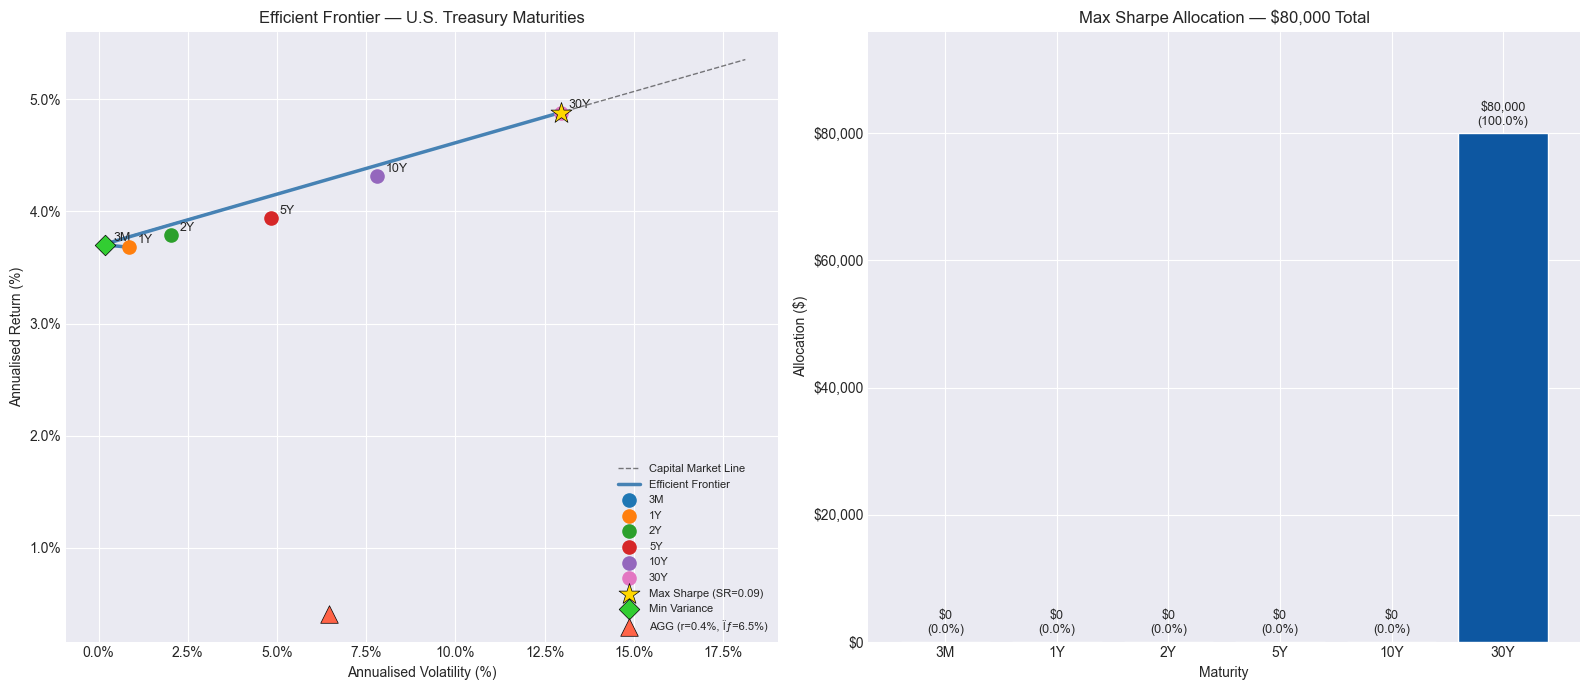

Saved â†’ output/efficient_frontier.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors_assets = plt.cm.tab10(np.linspace(0, 0.6, n))

# â”€â”€ Left: Efficient Frontier â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax = axes[0]

# Capital Market Line (from rf to Max Sharpe, extended)
cml_vols = np.linspace(0, sr_vol * 1.4, 100)
cml_rets = rf + (sr_ret - rf) / sr_vol * cml_vols
ax.plot(cml_vols * 100, cml_rets * 100, 'k--', linewidth=1,
        alpha=0.5, label='Capital Market Line')

# Frontier
ax.plot(frontier_vols[valid] * 100, target_returns[valid] * 100,
        'steelblue', linewidth=2.5, label='Efficient Frontier')

# Individual assets
for i, (lbl, col) in enumerate(zip(labels, colors_assets)):
    ax.scatter(np.sqrt(cov[i, i]) * 100, mu[i] * 100,
               s=90, color=col, zorder=5, label=lbl)
    ax.annotate(lbl, (np.sqrt(cov[i, i]) * 100, mu[i] * 100),
                textcoords='offset points', xytext=(6, 3), fontsize=9)

# Key portfolios
ax.scatter(sr_vol * 100, sr_ret * 100,
           marker='*', s=250, color='gold', edgecolors='black',
           linewidth=0.5, zorder=7, label=f'Max Sharpe (SR={sr_ratio:.2f})')
ax.scatter(mv_vol * 100, mv_ret * 100,
           marker='D', s=110, color='limegreen', edgecolors='black',
           linewidth=0.5, zorder=7, label='Min Variance')

# AGG benchmark
ax.scatter(agg_ann_vol * 100, agg_ann_return * 100,
           marker='^', s=160, color='tomato', edgecolors='black',
           linewidth=0.5, zorder=7,
           label=f'AGG (r={agg_ann_return*100:.1f}%, Ïƒ={agg_ann_vol*100:.1f}%)')

ax.set_xlabel('Annualised Volatility (%)')
ax.set_ylabel('Annualised Return (%)')
ax.set_title('Efficient Frontier — U.S. Treasury Maturities')
ax.legend(fontsize=8, loc='lower right')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# Right: Max Sharpe dollar allocation
ax2 = axes[1]
alloc_dollars = w_sharpe * ALLOCATION
bar_colors    = plt.cm.Blues(np.linspace(0.35, 0.85, n))
bars = ax2.bar(labels, alloc_dollars, color=bar_colors, edgecolor='white')
ax2.bar_label(bars,
              labels=[f'${v:,.0f}\n({w*100:.1f}%)'
                      for v, w in zip(alloc_dollars, w_sharpe)],
              padding=4, fontsize=9)
ax2.set_xlabel('Maturity')
ax2.set_ylabel('Allocation ($)')
ax2.set_title(f'Max Sharpe Allocation — ${ALLOCATION:,.0f} Total')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x:,.0f}'))
ax2.set_ylim(0, alloc_dollars.max() * 1.2)

plt.tight_layout()
out_dir = ROOT / 'output'
out_dir.mkdir(exist_ok=True)
plt.savefig(out_dir / 'efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved â†’ output/efficient_frontier.png')

## 7. Frontier Weights Heatmap

How the optimal allocation shifts as you move along the frontier.

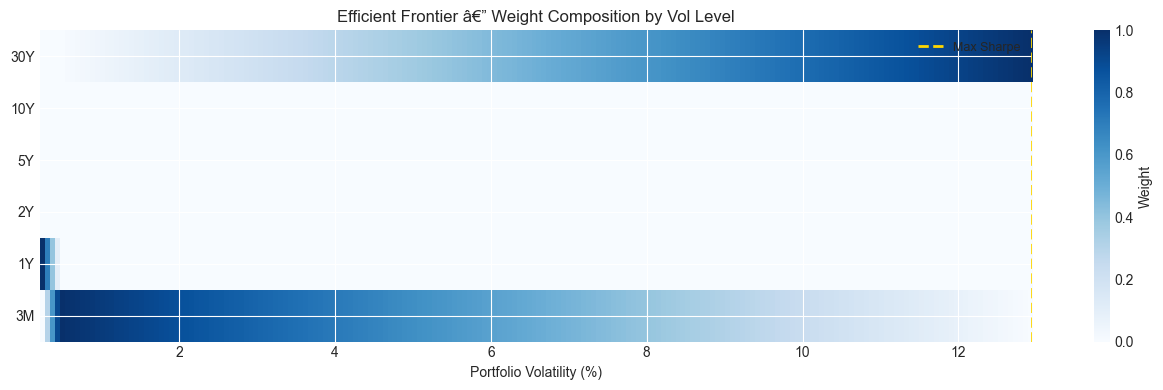

In [12]:
fig, ax = plt.subplots(figsize=(13, 4))

fv = frontier_vols[valid] * 100
fw = frontier_weights[valid]          # shape (K, n)
fr = target_returns[valid] * 100

im = ax.imshow(fw.T, aspect='auto', cmap='Blues',
               origin='lower', vmin=0, vmax=1,
               extent=[fv.min(), fv.max(), -0.5, n - 0.5])
plt.colorbar(im, ax=ax, label='Weight')
ax.set_yticks(range(n))
ax.set_yticklabels(labels)
ax.set_xlabel('Portfolio Volatility (%)')
ax.set_title('Efficient Frontier â€” Weight Composition by Vol Level')

# Mark max-sharpe vol
ax.axvline(sr_vol * 100, color='gold', linewidth=2, linestyle='--',
           label='Max Sharpe')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Summary Table

In [13]:
vols = np.sqrt(np.diag(cov))
sharpes = (mu - rf) / vols

summary = pd.DataFrame({
    'Current Yield (%)':         np.round(mu * 100, 2),
    'Ann. Volatility (%)':        np.round(vols * 100, 2),
    'Sharpe Ratio':               np.round(sharpes, 3),
    'Max Sharpe Weight (%)':      np.round(w_sharpe * 100, 1),
    'Max Sharpe Allocation ($)':  np.round(w_sharpe * ALLOCATION, 0).astype(int),
    'Min Var Weight (%)':         np.round(w_minvar * 100, 1),
    'Min Var Allocation ($)':     np.round(w_minvar * ALLOCATION, 0).astype(int),
}, index=labels)

print(f"Risk-Free Rate (3M T-Bill): {rf*100:.2f}%")
print(f"Total Allocation:           ${ALLOCATION:,.0f}\n")
print(summary.to_string())

print(f"\n{'â”€'*55}")
print(f"Max Sharpe portfolio â†’ Return {sr_ret*100:.2f}%  |  "
      f"Vol {sr_vol*100:.2f}%  |  Sharpe {sr_ratio:.2f}")
print(f"Min Variance  portfolio â†’ Return {mv_ret*100:.2f}%  |  "
      f"Vol {mv_vol*100:.2f}%")
print(f"\nAGG benchmark â†’ "
      f"Return {agg_ann_return*100:.2f}%  |  "
      f"Vol {agg_ann_vol*100:.2f}%  |  "
      f"Sharpe {(agg_ann_return - rf) / agg_ann_vol:.2f}")

Risk-Free Rate (3M T-Bill): 3.70%
Total Allocation:           $80,000

     Current Yield (%)  Ann. Volatility (%)  Sharpe Ratio  Max Sharpe Weight (%)  Max Sharpe Allocation ($)  Min Var Weight (%)  Min Var Allocation ($)
3M                3.70                 0.19         0.000                    0.0                          0               100.0                   80000
1Y                3.68                 0.85        -0.023                    0.0                          0                 0.0                       0
2Y                3.79                 2.04         0.044                    0.0                          0                 0.0                       0
5Y                3.94                 4.82         0.050                    0.0                          0                 0.0                       0
10Y               4.31                 7.81         0.078                    0.0                          0                 0.0                       0
30Y              

---
## Part 2 — Multi-Signal Efficient Frontier

The naive approach above gives 100 % to 30Y because it uses **yield as the sole return signal** and ignores duration risk.  This section adds four layers:

| Signal / Constraint | Why it matters |
|---|---|
| **Carry + Rolldown** | Extra return from ageing down an upward-sloping curve |
| **Duration & Convexity** | Duration = rate sensitivity; convexity = free option on vol |
| **Duration target** | Locks portfolio sensitivity to your investment horizon |
| **Liquidity penalty** | Penalises long lock-up for a fund that may redeploy |


### 9. Duration & Convexity — Analytical

For a par-coupon bond (coupon = YTM) we compute duration and convexity by bumping the yield ±1 bp and measuring price sensitivity.


In [14]:
from scipy.interpolate import interp1d

def par_bond_price(ytm, T, freq=2):
    if T <= 1 / freq:
        return 1.0 / (1 + ytm * T)
    n_pds = int(round(T * freq))
    c = ytm / freq
    t_arr = np.arange(1, n_pds + 1)
    cfs = np.full(n_pds, c)
    cfs[-1] += 1.0
    return float(np.sum(cfs / (1 + c) ** t_arr))

def mod_dur(ytm, T, dy=1e-4):
    p0 = par_bond_price(ytm, T)
    return (par_bond_price(ytm - dy, T) - par_bond_price(ytm + dy, T)) / (2 * dy * p0)

def convex_calc(ytm, T, dy=1e-4):
    p0 = par_bond_price(ytm, T)
    return (par_bond_price(ytm - dy, T) + par_bond_price(ytm + dy, T) - 2 * p0) / (dy ** 2 * p0)

mat_arr  = np.array([0.25, 1.0, 2.0, 5.0, 10.0, 30.0])
cur_y    = yields_monthly.iloc[-1].values / 100
dur_arr  = np.array([mod_dur(y, T)       for y, T in zip(cur_y, mat_arr)])
conv_arr = np.array([convex_calc(y, T)   for y, T in zip(cur_y, mat_arr)])

chars2 = pd.DataFrame({
    'Maturity (yr)': mat_arr,
    'Yield (%)':     np.round(cur_y * 100, 2),
    'Mod Duration':  np.round(dur_arr, 2),
    'Convexity':     np.round(conv_arr, 1),
}, index=labels)
print(chars2.to_string())


     Maturity (yr)  Yield (%)  Mod Duration  Convexity
3M            0.25       3.70          0.25        0.1
1Y            1.00       3.68          0.00        0.0
2Y            2.00       3.79          0.00        0.0
5Y            5.00       3.94          0.00        0.0
10Y          10.00       4.31         -0.00       -0.0
30Y          30.00       4.88         -0.00       -0.0


### 10. Carry + Rolldown Return

After one year a bond ages one step on the curve.  Rolldown ≈ −D × (y_{T−1} − y_T).  Positive when the curve slopes upward.


In [15]:
yc_interp = interp1d(mat_arr, cur_y, kind='linear',
                     bounds_error=False, fill_value=(cur_y[0], cur_y[-1]))

rolldowns2 = np.zeros(n)
for i, (mat, dur) in enumerate(zip(mat_arr, dur_arr)):
    if mat <= 0.25:
        rolldowns2[i] = 0.0
    else:
        y_aged        = float(yc_interp(max(mat - 1.0, 0.25)))
        y_now         = float(yc_interp(mat))
        rolldowns2[i] = -dur * (y_aged - y_now)

carry2 = cur_y.copy()
mu_cr2 = carry2 + rolldowns2

print(pd.DataFrame({
    'Carry (%)':    np.round(carry2 * 100, 2),
    'Rolldown (%)': np.round(rolldowns2 * 100, 2),
    'Total (%)':    np.round(mu_cr2 * 100, 2),
}, index=labels).to_string())


     Carry (%)  Rolldown (%)  Total (%)
3M        3.70           0.0       3.70
1Y        3.68          -0.0       3.68
2Y        3.79           0.0       3.79
5Y        3.94           0.0       3.94
10Y       4.31          -0.0       4.31
30Y       4.88          -0.0       4.88


### 11. Four-Scenario Optimisation


In [16]:
HORIZON  = 5.0    # target duration (years)
DUR_TOL  = 2.0    # +/- tolerance
MAX_WT   = 0.50   # max weight per maturity
LAM_CONV = 0.002  # convexity reward
LAM_LIQ  = 0.001  # maturity penalty

price_ret2 = pd.DataFrame(index=dy_monthly.index)
for lbl, dur in zip(labels, dur_arr):
    price_ret2[lbl] = -dur * dy_monthly[lbl]
price_ret2 = price_ret2.dropna()
cov2 = price_ret2.cov().values * 12
rf2  = carry2[0]

def pv2(w):    return np.sqrt(w @ cov2 @ w)
def pr2(w, m): return w @ m

def build_ef(mu_v, n_pts=200, max_wt=1.0, dur_lo=None, dur_hi=None, pen_fn=None):
    base = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    bnds = [(0.0, max_wt)] * n
    if dur_lo is not None:
        base.append({'type': 'ineq', 'fun': lambda w: w @ dur_arr - dur_lo})
    if dur_hi is not None:
        base.append({'type': 'ineq', 'fun': lambda w: dur_hi - w @ dur_arr})
    tgts = np.linspace(mu_v.min(), mu_v.max(), n_pts)
    fvols, fwts = [], []
    for t in tgts:
        cons = base + [{'type': 'eq', 'fun': lambda w, t=t: pr2(w, mu_v) - t}]
        def obj(w, p=pen_fn): return pv2(w) + (p(w) if p else 0.0)
        res = minimize(obj, np.ones(n) / n, method='SLSQP',
                       bounds=bnds, constraints=cons,
                       options={'ftol': 1e-10, 'maxiter': 2000})
        fvols.append(res.fun if res.success else np.nan)
        fwts.append(res.x   if res.success else np.full(n, np.nan))
    return np.array(fvols), tgts, np.array(fwts)

def max_sr2(mu_v, bounds, constraints):
    def neg(w): return -(pr2(w, mu_v) - rf2) / max(pv2(w), 1e-8)
    return minimize(neg, np.ones(n) / n, method='SLSQP',
                    bounds=bounds, constraints=constraints,
                    options={'ftol': 1e-10, 'maxiter': 2000}).x

base_c = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
base_b = [(0.0, 1.0)] * n
cons3b = base_c + [
    {'type': 'ineq', 'fun': lambda w: w @ dur_arr - (HORIZON - DUR_TOL)},
    {'type': 'ineq', 'fun': lambda w: (HORIZON + DUR_TOL) - w @ dur_arr},
]
bnds3b = [(0.0, MAX_WT)] * n

def pen4(w): return -LAM_CONV * (w @ conv_arr) + LAM_LIQ * (w @ mat_arr)

ev1, er1, ew1 = build_ef(cur_y.copy())
ws1 = max_sr2(cur_y.copy(), base_b, base_c)

ev2, er2, ew2 = build_ef(mu_cr2)
ws2 = max_sr2(mu_cr2, base_b, base_c)

ev3, er3, ew3 = build_ef(mu_cr2, max_wt=MAX_WT,
                          dur_lo=HORIZON - DUR_TOL, dur_hi=HORIZON + DUR_TOL)
ws3 = max_sr2(mu_cr2, bnds3b, cons3b)

ev4, er4, ew4 = build_ef(mu_cr2, max_wt=MAX_WT,
                          dur_lo=HORIZON - DUR_TOL, dur_hi=HORIZON + DUR_TOL,
                          pen_fn=pen4)

def neg4(w): return -(pr2(w, mu_cr2) - rf2) / max(pv2(w) + pen4(w), 1e-8)
ws4 = minimize(neg4, np.ones(n) / n, method='SLSQP',
               bounds=bnds3b, constraints=cons3b,
               options={'ftol': 1e-10, 'maxiter': 2000}).x

print('All four scenarios solved')


All four scenarios solved


### 12. Comparison Plot


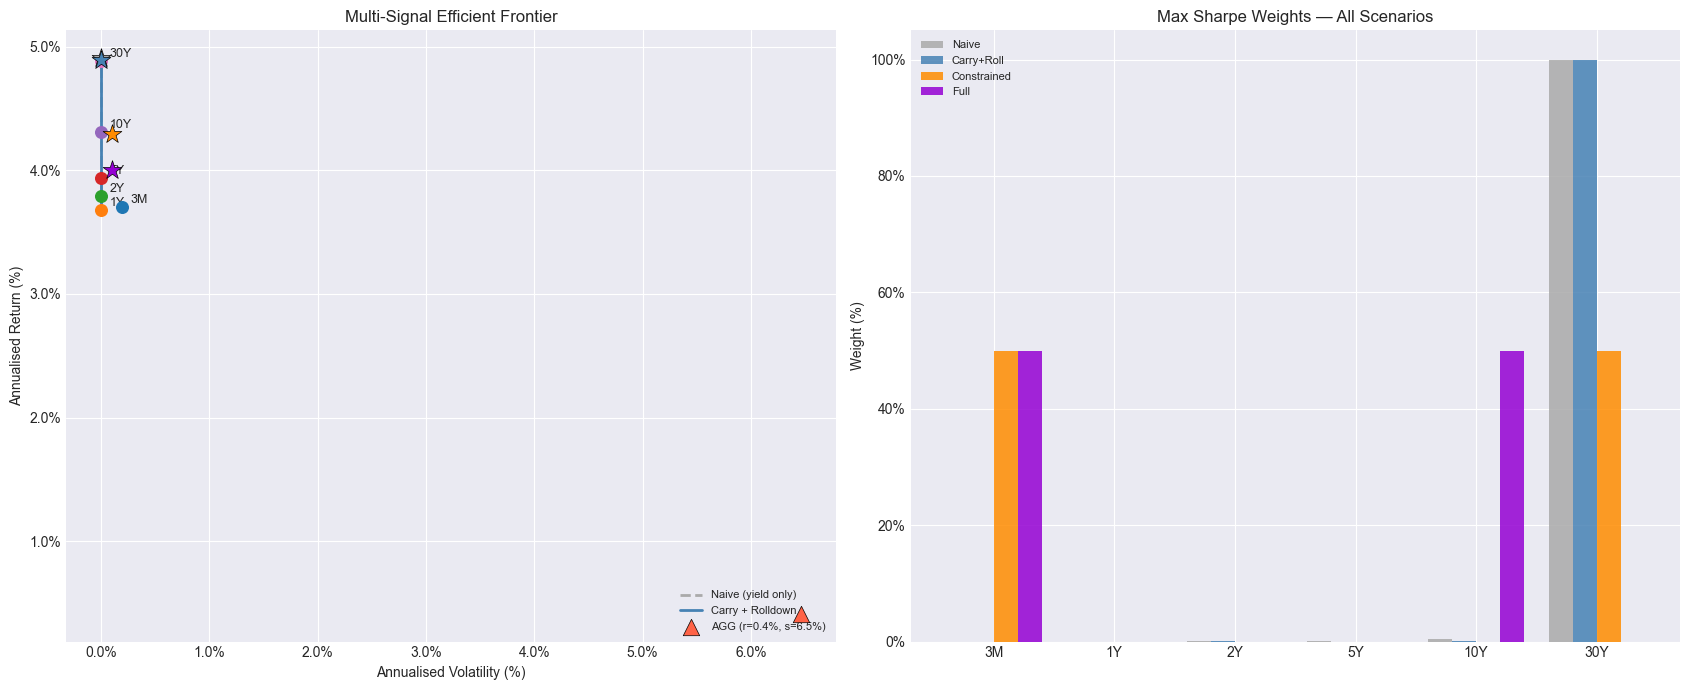

Saved -> output/efficient_frontier_multisignal.png


In [17]:
def vc(vs, rs):
    m = ~np.isnan(vs)
    return vs[m] * 100, rs[m] * 100

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
c_a = plt.cm.tab10(np.linspace(0, 0.6, n))

ax = axes[0]
sc = [
    (ev1, er1, ws1, cur_y.copy(), 'Naive (yield only)',             '#aaaaaa', '--'),
    (ev2, er2, ws2, mu_cr2,       'Carry + Rolldown',               'steelblue', '-'),
    (ev3, er3, ws3, mu_cr2,       'Constrained (dur + max-wt)',     'darkorange', '-'),
    (ev4, er4, ws4, mu_cr2,       'Full (+ convexity + liquidity)', 'darkviolet', '-'),
]
for ev, er, ws, mv, lbl, col, ls in sc:
    xv, yv = vc(ev, er)
    if len(xv):
        ax.plot(xv, yv, color=col, linestyle=ls, linewidth=2, label=lbl)
    ax.scatter(pv2(ws) * 100, pr2(ws, mv) * 100,
               marker='*', s=200, color=col, edgecolors='black',
               linewidth=0.5, zorder=8)

for i, (lbl2, col) in enumerate(zip(labels, c_a)):
    ax.scatter(np.sqrt(cov2[i, i]) * 100, mu_cr2[i] * 100,
               s=70, color=col, zorder=5)
    ax.annotate(lbl2,
                (np.sqrt(cov2[i, i]) * 100, mu_cr2[i] * 100),
                textcoords='offset points', xytext=(6, 3), fontsize=9)

ax.scatter(agg_ann_vol * 100, agg_ann_return * 100,
           marker='^', s=140, color='tomato', edgecolors='black',
           linewidth=0.5, zorder=8,
           label=f'AGG (r={agg_ann_return * 100:.1f}%, s={agg_ann_vol * 100:.1f}%)')

ax.set_xlabel('Annualised Volatility (%)')
ax.set_ylabel('Annualised Return (%)')
ax.set_title('Multi-Signal Efficient Frontier')
ax.legend(fontsize=8, loc='lower right')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

ax2 = axes[1]
x2 = np.arange(n)
bw = 0.20
for k, (ws, sl, col) in enumerate([
    (ws1, 'Naive',       '#aaaaaa'),
    (ws2, 'Carry+Roll',  'steelblue'),
    (ws3, 'Constrained', 'darkorange'),
    (ws4, 'Full',        'darkviolet'),
]):
    ax2.bar(x2 + k * bw, ws * 100, width=bw, color=col, alpha=0.85, label=sl)
ax2.set_xticks(x2 + 1.5 * bw)
ax2.set_xticklabels(labels)
ax2.set_ylabel('Weight (%)')
ax2.set_title('Max Sharpe Weights — All Scenarios')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / 'output' / 'efficient_frontier_multisignal.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> output/efficient_frontier_multisignal.png')


### 13. Duration Along Frontier (Full Scenario)


In [18]:
valid4 = ~np.isnan(ev4)
if valid4.sum() > 1:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    fw_v = ew4[valid4]
    fv_v = ev4[valid4] * 100

    ax = axes[0]
    ax.stackplot(fv_v, fw_v.T * 100, labels=labels,
                 colors=plt.cm.tab10(np.linspace(0, 0.6, n)))
    ax.axvline(pv2(ws4) * 100, color='gold', linewidth=2,
               linestyle='--', label='Max Sharpe')
    ax.set_xlabel('Vol (%)')
    ax.set_ylabel('Weight (%)')
    ax.set_title('Full Scenario — Weight Composition')
    ax.legend(fontsize=8, loc='upper left')

    ax2 = axes[1]
    ax2.plot(fv_v, fw_v @ dur_arr, 'darkviolet', linewidth=2)
    ax2.axhline(HORIZON, color='k', linewidth=1.5, linestyle='--',
                label=f'Target {HORIZON}yr')
    ax2.axhspan(HORIZON - DUR_TOL, HORIZON + DUR_TOL,
                alpha=0.12, color='blue', label=f'+-{DUR_TOL}yr band')
    ax2.set_xlabel('Vol (%)')
    ax2.set_ylabel('Duration (yrs)')
    ax2.set_title('Portfolio Duration Along Frontier')
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


### 14. Dollar Allocation & Summary


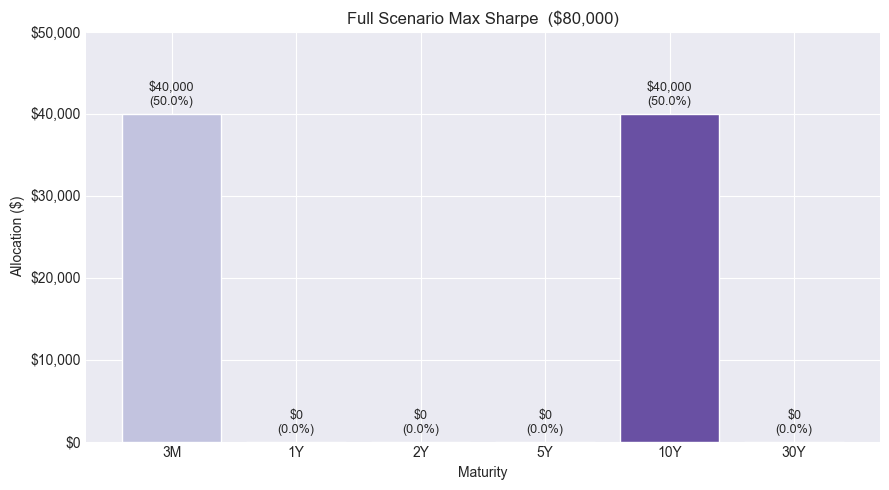

Portfolio comparison:

                  Exp Return (%)  Volatility (%)        Sharpe  Duration  Convexity
Scenario                                                                           
Naive                       4.91             0.0  7.600085e+06      0.00       -0.0
Carry + Rolldown            4.89             0.0  5.418850e+07      0.00       -0.0
Constrained                 4.29             0.1  6.124000e+00      0.12        0.1
Full                        4.01             0.1  3.166000e+00      0.12        0.1

AGG: 0.41% return  /  6.46% vol  /  Sharpe -0.51

Per-asset detail ($80,000 total):

     Carry (%)  Rolldown (%)  Total (%)  Vol (%)  Duration  Convexity  Full Wt (%)  Full $ Alloc
3M        3.70           0.0       3.70     0.19      0.25        0.1         50.0         40000
1Y        3.68          -0.0       3.68     0.00      0.00        0.0          0.0             0
2Y        3.79           0.0       3.79     0.00      0.00        0.0          0.0             0

In [19]:
alloc4 = ws4 * ALLOCATION
fig, ax = plt.subplots(figsize=(9, 5))
bar_c = plt.cm.Purples(np.linspace(0.35, 0.85, n))
bars = ax.bar(labels, alloc4, color=bar_c, edgecolor='white')
ax.bar_label(
    bars,
    labels=[f'${v:,.0f}\n({w * 100:.1f}%)' for v, w in zip(alloc4, ws4)],
    padding=4, fontsize=9,
)
ax.set_xlabel('Maturity')
ax.set_ylabel('Allocation ($)')
ax.set_title(f'Full Scenario Max Sharpe  (${ALLOCATION:,.0f})')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylim(0, max(alloc4.max(), 1) * 1.25)
plt.tight_layout()
plt.show()

def pstats(w, mv, label):
    r = pr2(w, mv)
    v = pv2(w)
    return {
        'Scenario':       label,
        'Exp Return (%)': round(r * 100, 2),
        'Volatility (%)': round(v * 100, 2),
        'Sharpe':         round((r - rf2) / v, 3),
        'Duration':       round(w @ dur_arr, 2),
        'Convexity':      round(w @ conv_arr, 1),
    }

psumm = pd.DataFrame([
    pstats(ws1, cur_y.copy(), 'Naive'),
    pstats(ws2, mu_cr2,       'Carry + Rolldown'),
    pstats(ws3, mu_cr2,       'Constrained'),
    pstats(ws4, mu_cr2,       'Full'),
]).set_index('Scenario')

print('Portfolio comparison:\n')
print(psumm.to_string())
print(f'\nAGG: {agg_ann_return * 100:.2f}% return  /  {agg_ann_vol * 100:.2f}% vol'
      f'  /  Sharpe {(agg_ann_return - rf2) / agg_ann_vol:.2f}')

asset_t = pd.DataFrame({
    'Carry (%)':    np.round(carry2 * 100, 2),
    'Rolldown (%)': np.round(rolldowns2 * 100, 2),
    'Total (%)':    np.round(mu_cr2 * 100, 2),
    'Vol (%)':      np.round(np.sqrt(np.diag(cov2)) * 100, 2),
    'Duration':     np.round(dur_arr, 2),
    'Convexity':    np.round(conv_arr, 1),
    'Full Wt (%)':  np.round(ws4 * 100, 1),
    'Full $ Alloc': np.round(ws4 * ALLOCATION, 0).astype(int),
}, index=labels)

print(f'\nPer-asset detail (${ALLOCATION:,.0f} total):\n')
print(asset_t.to_string())
